In [1]:
import pandas as pd

train_path = "../data/train_set.csv"
train_df = pd.read_csv(train_path)
train_df.shape

(100252, 154)

In [2]:
list(train_df.columns)

['model',
 'input_dimensions',
 'input_dtypes',
 'output_dimensions',
 'output_dtypes',
 'conv_flops',
 'matmul_flops',
 'elementwise_mb',
 'reduction_mb',
 'normalization_mb',
 'movement_mb',
 'Abs',
 'Acos',
 'Add',
 'ai.onnx.ml::CategoryMapper',
 'And',
 'ArgMax',
 'AveragePool',
 'BatchNormalization',
 'Cast',
 'Ceil',
 'Clip',
 'com.microsoft::BiasGelu',
 'com.microsoft::DynamicQuantizeLSTM',
 'com.microsoft::DynamicQuantizeMatMul',
 'com.microsoft::FastGelu',
 'com.microsoft::FusedConv',
 'com.microsoft::FusedGemm',
 'com.microsoft::FusedMatMul',
 'com.microsoft::MatMulIntegerToFloat',
 'com.microsoft::QGemm',
 'com.microsoft::QLinearAdd',
 'com.microsoft::QLinearAveragePool',
 'com.microsoft::QLinearConcat',
 'com.microsoft::QLinearGlobalAveragePool',
 'com.microsoft::QLinearLeakyRelu',
 'com.microsoft::QLinearMul',
 'com.microsoft::QLinearSigmoid',
 'com.microsoft::QuickGelu',
 'com.microsoft::SkipLayerNormalization',
 'Compress',
 'Concat',
 'Constant',
 'ConstantOfShape',
 'C

In [3]:
# Remove non-predictive columns from the dataset
columns_to_remove = ['run_id', 'repo_file', 'model']
train_df = train_df.drop(columns=columns_to_remove)

print(f"Removed columns: {columns_to_remove}")
print(f"Dataset shape after removal: {train_df.shape}")

Removed columns: ['run_id', 'repo_file', 'model']
Dataset shape after removal: (100252, 151)


In [4]:
# Feature type detection
numeric_features = train_df.select_dtypes(include=['number']).columns.tolist()
string_features = train_df.select_dtypes(include=['object']).columns.tolist()

print(f"Total features: {len(numeric_features) + len(string_features)}")
print(f"Numeric features: {len(numeric_features)}")
print(f"String features: {len(string_features)}")
print(f"\nString features: {string_features}")

Total features: 151
Numeric features: 144
String features: 7

String features: ['input_dimensions', 'input_dtypes', 'output_dimensions', 'output_dtypes', 'cpu_provider', 'machine_type', 'platform']


/var/folders/0x/zyc_hp8x2s51jk5035q4p4_h0000gn/T/ipykernel_40989/1938926771.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_features = train_df.select_dtypes(include=['object']).columns.tolist()


In [5]:
# Analyze numerical features in detail
if numeric_features:
    numeric_df = train_df[numeric_features]
    
    # Calculate metrics
    sparsity = (numeric_df == 0).mean() * 100  # Convert to percentage
    skewness = numeric_df.skew()
    variance = numeric_df.var()
    
    # Create comprehensive numerical summary
    numerical_summary = pd.DataFrame({
        'feature': numeric_features,
        'zero_pct': sparsity.values,
        'skewness': skewness.values,
        'variance': variance.values,
        'unique_values': [numeric_df[col].nunique() for col in numeric_features],
        'min': numeric_df.min().values,
        'max': numeric_df.max().values,
        'mean': numeric_df.mean().values,
        'std': numeric_df.std().values,
        'range': numeric_df.max().values - numeric_df.min().values
    })
    
    # Categorize features
    def categorize_feature(row):
        if row['unique_values'] <= 1:
            return 'near_constant'
        if row['zero_pct'] >= 95:
            return 'ultra_sparse'
        elif row['zero_pct'] >= 50:
            return 'sparse'
        else:
            return 'dense'
    
    numerical_summary['category'] = numerical_summary.apply(categorize_feature, axis=1)
    numerical_summary['highly_skewed'] = abs(numerical_summary['skewness']) > 2
    numerical_summary['variance_flag'] = numerical_summary['variance'] < 1e-6  # Near-zero variance
else:
    numerical_summary = pd.DataFrame()
    numeric_df = None

print("Numerical analysis complete. Summary shape:", numerical_summary.shape)

Numerical analysis complete. Summary shape: (144, 13)


In [6]:
# Analyze string/categorical features
if string_features:
    string_summary = pd.DataFrame({
        'feature': string_features,
        'unique_values': [train_df[col].nunique() for col in string_features],
        'missing_count': [train_df[col].isna().sum() for col in string_features],
        'missing_pct': [(train_df[col].isna().sum() / len(train_df) * 100) for col in string_features],
        'most_common_value': [train_df[col].value_counts().index[0] if len(train_df[col].value_counts()) > 0 else 'N/A' for col in string_features],
        'most_common_freq': [train_df[col].value_counts().iloc[0] / len(train_df) * 100 if len(train_df[col].value_counts()) > 0 else 0 for col in string_features]
    })
    
    # Categorize string features by cardinality
    def categorize_string(row):
        if row['unique_values'] <= 2:
            return 'binary_or_constant'
        elif row['unique_values'] <= 10:
            return 'low_cardinality'
        elif row['unique_values'] <= 100:
            return 'medium_cardinality'
        else:
            return 'high_cardinality'
    
    string_summary['category'] = string_summary.apply(categorize_string, axis=1)
else:
    string_summary = pd.DataFrame()

print("String features analysis complete. Summary shape:", string_summary.shape)

String features analysis complete. Summary shape: (7, 7)


In [7]:
# NUMERICAL FEATURES SUMMARY
print("="*80)
print("NUMERICAL FEATURES BREAKDOWN")
print("="*80)

if not numerical_summary.empty:
    # Category counts
    category_counts = numerical_summary['category'].value_counts()
    print("\nCategory Distribution:")
    for cat, count in category_counts.items():
        print(f"  {cat.upper()}: {count} features")
    
    print("\n" + "-"*80)
    print("ULTRA-SPARSE (>=95% zeros):")
    ultra_sparse = numerical_summary[numerical_summary['category'] == 'ultra_sparse'].sort_values('zero_pct', ascending=False)
    print(f"  Count: {len(ultra_sparse)} features")
    if len(ultra_sparse) > 0:
        print(f"  Examples (top 5): {ultra_sparse['feature'].head(5).tolist()}")
        print(f"  Sparsity range: {ultra_sparse['zero_pct'].min():.1f}% - {ultra_sparse['zero_pct'].max():.1f}%")
    
    print("\n" + "-"*80)
    print("SPARSE (50-95% zeros):")
    sparse = numerical_summary[numerical_summary['category'] == 'sparse'].sort_values('zero_pct', ascending=False)
    print(f"  Count: {len(sparse)} features")
    if len(sparse) > 0:
        print(f"  Examples (top 5): {sparse['feature'].head(5).tolist()}")
        print(f"  Sparsity range: {sparse['zero_pct'].min():.1f}% - {sparse['zero_pct'].max():.1f}%")
    
    print("\n" + "-"*80)
    print("DENSE (<50% zeros):")
    dense = numerical_summary[numerical_summary['category'] == 'dense'].sort_values('zero_pct', ascending=False)
    print(f"  Count: {len(dense)} features")
    if len(dense) > 0:
        print(f"  Examples (top 5): {dense['feature'].head(5).tolist()}")
        print(f"  Sparsity range: {dense['zero_pct'].min():.1f}% - {dense['zero_pct'].max():.1f}%")
    
    print("\n" + "-"*80)
    print("NEAR-CONSTANT (<=1 unique value or ~zero variance):")
    near_const = numerical_summary[numerical_summary['category'] == 'near_constant']
    print(f"  Count: {len(near_const)} features")
    if len(near_const) > 0:
        print(f"  Features: {near_const['feature'].tolist()}")
    
    print("\n" + "-"*80)
    print("HIGHLY SKEWED (|skewness| > 2):")
    highly_skewed = numerical_summary[numerical_summary['highly_skewed']].sort_values('skewness', key=abs, ascending=False)
    print(f"  Count: {len(highly_skewed)} features")
    if len(highly_skewed) > 0:
        print(f"  Top 10 most skewed features:")
        for idx, row in highly_skewed.head(10).iterrows():
            print(f"    {row['feature']:40s} | skewness: {row['skewness']:8.2f} | category: {row['category']}")
    
    print("\n" + "-"*80)
    print("ZERO VARIANCE (likely uninformative):")
    zero_var = numerical_summary[numerical_summary['variance_flag']]
    print(f"  Count: {len(zero_var)} features")
    if len(zero_var) > 0:
        print(f"  Features: {zero_var['feature'].tolist()}")
else:
    print("No numerical features found.")

print("\n" + "="*80)
print("STRING/CATEGORICAL FEATURES SUMMARY")
print("="*80)

if not string_summary.empty:
    # Category counts
    str_category_counts = string_summary['category'].value_counts()
    print("\nCategory Distribution:")
    for cat, count in str_category_counts.items():
        print(f"  {cat.upper()}: {count} features")
    
    print("\n" + "-"*80)
    print("ALL STRING FEATURES DETAILED VIEW:")
    for idx, row in string_summary.iterrows():
        print(f"\n  {row['feature']}:")
        print(f"    Unique values: {row['unique_values']}")
        print(f"    Missing: {row['missing_count']} ({row['missing_pct']:.1f}%)")
        print(f"    Most common: '{row['most_common_value']}' ({row['most_common_freq']:.1f}%)")
        print(f"    Category: {row['category']}")
else:
    print("No string features found.")

NUMERICAL FEATURES BREAKDOWN

Category Distribution:
  ULTRA_SPARSE: 80 features
  SPARSE: 37 features
  DENSE: 24 features
  NEAR_CONSTANT: 3 features

--------------------------------------------------------------------------------
ULTRA-SPARSE (>=95% zeros):
  Count: 80 features
  Examples (top 5): ['com.microsoft::DynamicQuantizeMatMul', 'com.microsoft::MatMulIntegerToFloat', 'com.microsoft::QGemm', 'com.microsoft::BiasGelu', 'MatMulInteger']
  Sparsity range: 95.6% - 100.0%

--------------------------------------------------------------------------------
SPARSE (50-95% zeros):
  Count: 37 features
  Examples (top 5): ['Identity', 'com.microsoft::SkipLayerNormalization', 'com.microsoft::FusedMatMul', 'Abs', 'ReduceSum']
  Sparsity range: 51.5% - 94.7%

--------------------------------------------------------------------------------
DENSE (<50% zeros):
  Count: 24 features
  Examples (top 5): ['normalization_mb', 'Reshape', 'GlobalAveragePool', 'Mul', 'Flatten']
  Sparsity range: 0.

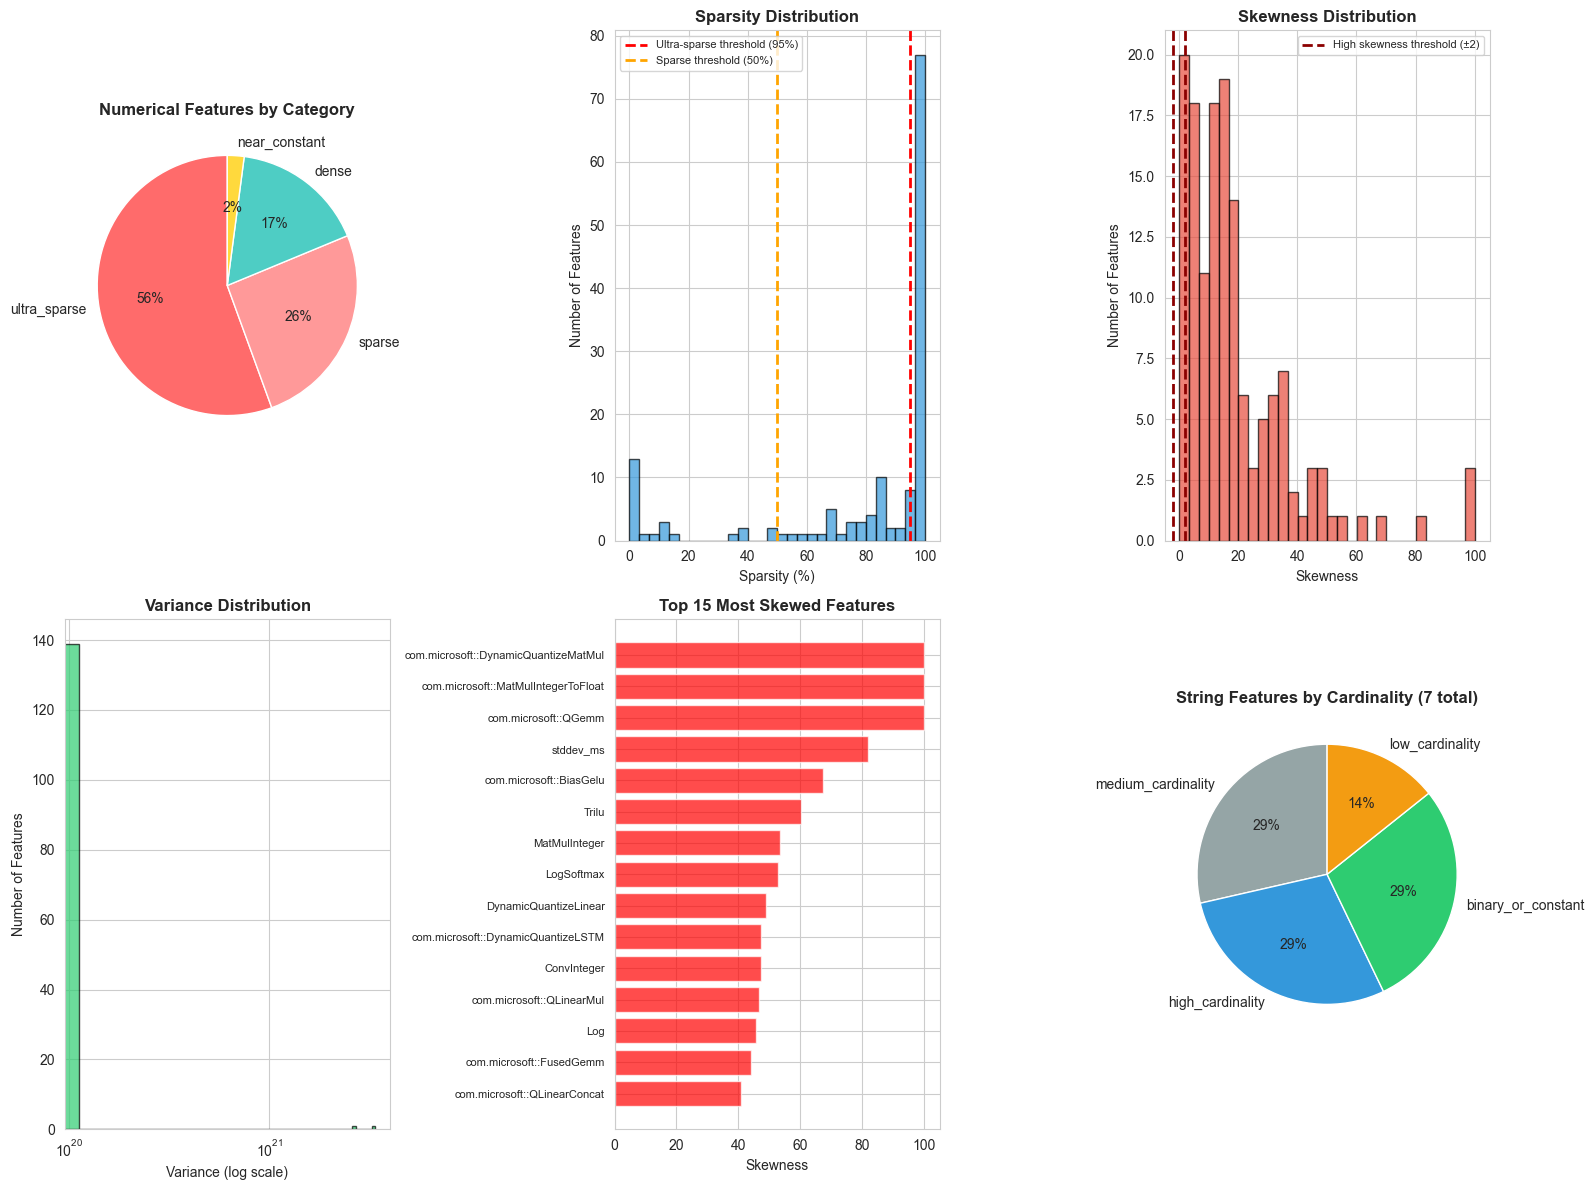

Visualizations generated successfully!


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
fig = plt.figure(figsize=(16, 12))

# 1. Pie chart of numerical feature categories
if not numerical_summary.empty:
    ax1 = plt.subplot(2, 3, 1)
    category_counts = numerical_summary['category'].value_counts()
    colors = ['#ff6b6b', '#ff9999', '#4ecdc4', '#ffd93d', '#6c5ce7']
    ax1.pie(category_counts.values, labels=category_counts.index, autopct='%1.0f%%', 
            colors=colors[:len(category_counts)], startangle=90)
    ax1.set_title('Numerical Features by Category', fontsize=12, fontweight='bold')

# 2. Histogram of sparsity
if not numerical_summary.empty:
    ax2 = plt.subplot(2, 3, 2)
    ax2.hist(numerical_summary['zero_pct'], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
    ax2.axvline(95, color='red', linestyle='--', linewidth=2, label='Ultra-sparse threshold (95%)')
    ax2.axvline(50, color='orange', linestyle='--', linewidth=2, label='Sparse threshold (50%)')
    ax2.set_xlabel('Sparsity (%)')
    ax2.set_ylabel('Number of Features')
    ax2.set_title('Sparsity Distribution', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=8)

# 3. Skewness distribution
if not numerical_summary.empty:
    ax3 = plt.subplot(2, 3, 3)
    skew_data = numerical_summary['skewness'].dropna()
    ax3.hist(skew_data, bins=30, color='#e74c3c', edgecolor='black', alpha=0.7)
    ax3.axvline(2, color='darkred', linestyle='--', linewidth=2, label='High skewness threshold (±2)')
    ax3.axvline(-2, color='darkred', linestyle='--', linewidth=2)
    ax3.set_xlabel('Skewness')
    ax3.set_ylabel('Number of Features')
    ax3.set_title('Skewness Distribution', fontsize=12, fontweight='bold')
    ax3.legend(fontsize=8)

# 4. Variance distribution (log scale)
if not numerical_summary.empty:
    ax4 = plt.subplot(2, 3, 4)
    variance_data = numerical_summary['variance'].dropna()
    variance_data = variance_data[variance_data > 0]  # Remove zeros for log scale
    ax4.hist(variance_data, bins=30, color='#2ecc71', edgecolor='black', alpha=0.7)
    ax4.set_xscale('log')
    ax4.set_xlabel('Variance (log scale)')
    ax4.set_ylabel('Number of Features')
    ax4.set_title('Variance Distribution', fontsize=12, fontweight='bold')

# 5. Top most-skewed features
if not numerical_summary.empty and numerical_summary['highly_skewed'].sum() > 0:
    ax5 = plt.subplot(2, 3, 5)
    highly_skewed = numerical_summary[numerical_summary['highly_skewed']].sort_values('skewness', key=abs, ascending=True).tail(15)
    colors_skew = ['red' if abs(x) > 5 else 'orange' for x in highly_skewed['skewness']]
    ax5.barh(range(len(highly_skewed)), highly_skewed['skewness'].values, color=colors_skew, alpha=0.7)
    ax5.set_yticks(range(len(highly_skewed)))
    ax5.set_yticklabels(highly_skewed['feature'].values, fontsize=8)
    ax5.set_xlabel('Skewness')
    ax5.set_title('Top 15 Most Skewed Features', fontsize=12, fontweight='bold')
    ax5.axvline(0, color='black', linestyle='-', linewidth=0.5)

# 6. String feature cardinality
if not string_summary.empty:
    ax6 = plt.subplot(2, 3, 6)
    str_category_counts = string_summary['category'].value_counts()
    colors_str = ['#95a5a6', '#3498db', '#2ecc71', '#f39c12']
    ax6.pie(str_category_counts.values, labels=str_category_counts.index, autopct='%1.0f%%',
            colors=colors_str[:len(str_category_counts)], startangle=90)
    ax6.set_title(f'String Features by Cardinality ({len(string_features)} total)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Visualizations generated successfully!")

In [9]:
# FINAL SUMMARY AND FEATURE QUALITY ASSESSMENT

print("\n" + "="*80)
print("FINAL SUMMARY FOR INFERENCE TIME PREDICTION MODEL")
print("="*80)

print("\nDATASET OVERVIEW:")
print(f"  Total samples: {len(train_df):,}")
print(f"  Total features: {len(train_df.columns)}")
print(f"    - Numerical: {len(numeric_features)}")
print(f"    - Categorical/String: {len(string_features)}")

print("\nFEATURE QUALITY ASSESSMENT FOR PREDICTIVE MODELING:")
print("-" * 80)

# High-value features
if not numerical_summary.empty:
    high_value = numerical_summary[
        (numerical_summary['category'] == 'dense') &
        (~numerical_summary['highly_skewed']) &
        (~numerical_summary['variance_flag'])
    ]
    print(f"\n✓ RECOMMENDED (Dense, stable, low skew): {len(high_value)} features")
    if len(high_value) > 0:
        print(f"  Examples: {high_value['feature'].head(8).tolist()}")
    
    # Sparse but potentially useful
    sparse_features = numerical_summary[
        (numerical_summary['category'].isin(['sparse', 'ultra_sparse'])) &
        (~numerical_summary['highly_skewed'])
    ]
    print(f"\n⚠ POTENTIALLY USEFUL (Sparse but low skew): {len(sparse_features)} features")
    print(f"  May need feature engineering (e.g., log transform, binarization)")
    if len(sparse_features) > 0:
        print(f"  Examples: {sparse_features['feature'].head(5).tolist()}")
    
    # Problem features
    problem_features = numerical_summary[
        (numerical_summary['highly_skewed']) |
        (numerical_summary['variance_flag']) |
        (numerical_summary['category'] == 'near_constant')
    ]
    print(f"\n✗ PROBLEMATIC: {len(problem_features)} features")
    print(f"  Highly skewed: {numerical_summary['highly_skewed'].sum()}")
    print(f"  Near-zero variance: {numerical_summary['variance_flag'].sum()}")
    print(f"  Near-constant: {(numerical_summary['category'] == 'near_constant').sum()}")
    print(f"  Action: Consider removing or transforming these features")

print("\n" + "-"*80)
print("MODELING RECOMMENDATIONS FOR ONNX INFERENCE TIME PREDICTION:")
print("-"*80)
print("""
1. NODE COUNTS & MODEL STRUCTURE:
   - Expect many node-count features (likely sparse, highly variable)
   - These are likely core predictors for inference time
   - May need normalization/log transforms due to skewness

2. TENSOR SIZES:
   - Likely have high variance, may be sparse if not all models use all layers
   - Check if any tensor size features are near-constant (indicates limited diversity in models)

3. MACHINE SPECS (core count, cache, RAM):
   - Should be dense features from metadata
   - Good candidates for direct use in model

4. FEATURE ENGINEERING IDEAS:
   - Log-transform highly skewed sparse features
   - Create interaction terms between model complexity and machine specs
   - Consider PCA/dimensionality reduction for ultra-sparse features
   - Group similar node types for better signal

5. CLASS IMBALANCE / TARGET DISTRIBUTION:
   - Check if inference time is heavily skewed (likely for fast vs. slow models)
   - May need special handling in loss function
""")

print("\n" + "="*80)


FINAL SUMMARY FOR INFERENCE TIME PREDICTION MODEL

DATASET OVERVIEW:
  Total samples: 100,252
  Total features: 151
    - Numerical: 144
    - Categorical/String: 7

FEATURE QUALITY ASSESSMENT FOR PREDICTIVE MODELING:
--------------------------------------------------------------------------------

✓ RECOMMENDED (Dense, stable, low skew): 7 features
  Examples: ['num_cores', 'memory_mb', 'l1d_cache_kb', 'l1i_cache_kb', 'l2_cache_kb', 'base_clock_mhz', 'memory_bandwith_gbs']

⚠ POTENTIALLY USEFUL (Sparse but low skew): 1 features
  May need feature engineering (e.g., log transform, binarization)
  Examples: ['LayerNormalization']

✗ PROBLEMATIC: 136 features
  Highly skewed: 133
  Near-zero variance: 3
  Near-constant: 3
  Action: Consider removing or transforming these features

--------------------------------------------------------------------------------
MODELING RECOMMENDATIONS FOR ONNX INFERENCE TIME PREDICTION:
-------------------------------------------------------------------

In [10]:
# Quick reference summary
print("QUICK REFERENCE SUMMARY")
print("=" * 80)

if not numerical_summary.empty:
    cat_dist = numerical_summary['category'].value_counts()
    print("\nNumerical Features (145 total):")
    for cat in ['dense', 'sparse', 'ultra_sparse', 'near_constant']:
        count = cat_dist.get(cat, 0)
        pct = count / len(numerical_summary) * 100
        print(f"  {cat:15s}: {count:3d} ({pct:5.1f}%)")
    
    skew_count = numerical_summary['highly_skewed'].sum()
    print(f"  Highly skewed (|skew|>2): {skew_count}")
    print(f"  Zero variance: {numerical_summary['variance_flag'].sum()}")

if not string_summary.empty:
    print(f"\nString Features (9 total):")
    str_dist = string_summary['category'].value_counts()
    for cat in ['binary_or_constant', 'low_cardinality', 'medium_cardinality', 'high_cardinality']:
        count = str_dist.get(cat, 0)
        if count > 0:
            pct = count / len(string_summary) * 100
            print(f"  {cat:20s}: {count} ({pct:5.1f}%)")

QUICK REFERENCE SUMMARY

Numerical Features (145 total):
  dense          :  24 ( 16.7%)
  sparse         :  37 ( 25.7%)
  ultra_sparse   :  80 ( 55.6%)
  near_constant  :   3 (  2.1%)
  Highly skewed (|skew|>2): 133
  Zero variance: 3

String Features (9 total):
  binary_or_constant  : 2 ( 28.6%)
  low_cardinality     : 1 ( 14.3%)
  medium_cardinality  : 2 ( 28.6%)
  high_cardinality    : 2 ( 28.6%)
